In [1]:
from pathlib import Path

import pandas as pd
import duckdb

In [2]:
# I am setting the project folder paths so the notebook can find the cleaned datasets.

current_path = Path.cwd()

if current_path.name == "notebooks":
    BASE_DIR = current_path.parent
else:
    BASE_DIR = current_path

PROCESSED_DIR = BASE_DIR / "data" / "processed"

season_path = PROCESSED_DIR / "afl_season_attendance_clean.csv"
match_path = PROCESSED_DIR / "afl_match_attendance_clean.csv"

print("Base folder:", BASE_DIR)
print("Season dataset path:", season_path)
print("Match dataset path:", match_path)

Base folder: C:\Users\DELL\afl-attendance-analytics
Season dataset path: C:\Users\DELL\afl-attendance-analytics\data\processed\afl_season_attendance_clean.csv
Match dataset path: C:\Users\DELL\afl-attendance-analytics\data\processed\afl_match_attendance_clean.csv


In [3]:
# I am loading the cleaned season-level and match-level datasets created in the cleaning notebook.

season_df = pd.read_csv(season_path)
match_df = pd.read_csv(match_path)

print("Season dataset shape:", season_df.shape)
print("Match dataset shape:", match_df.shape)

display(season_df.head())
display(match_df.head())

Season dataset shape: (106, 15)
Match dataset shape: (2813, 21)


,season,home_away_attendance,home_away_games,home_away_average,home_away_change,finals_attendance,finals_games,finals_average,finals_change,overall_attendance,overall_games,overall_average,overall_change,covid_affected,included_in_main_analysis
0,1921,1175408,72,16325,NaN,165450.0,4.0,41363.0,NaN,1340858,76,17643,NaN,False,False
1,1922,1324792,72,18400,12.7,207278.0,4.0,51820.0,25.3,1532070,76,20159,14.3,False,False
2,1923,1331426,72,18492,0.5,213462.0,4.0,53366.0,3.0,1544888,76,20327,0.8,False,False
3,1924,1475541,72,20494,10.8,170732.0,6.0,28455.0,-46.7,1646273,78,21106,3.8,False,False
4,1925,1645904,102,16136,-21.3,225432.0,4.0,56358.0,98.1,1871336,106,17654,-16.4,False,False


,season,year,round,match_type,final_stage,is_final,home_team,away_team,home_score,away_score,...,margin,result_type,match_day,match_date,month,match_time,attendance,venue,covid_affected,included_in_main_analysis
0,2012,2012,1.0,Home & Away,Not applicable,False,Greater Western Sydney,Sydney,37,100,...,63,Win,Sat,2012-03-24,March,7:20 PM,38203,Stadium Australia,False,True
1,2012,2012,1.0,Home & Away,Not applicable,False,Richmond,Carlton,81,125,...,44,Win,Thu,2012-03-29,March,7:45 PM,78285,M.C.G.,False,True
2,2012,2012,1.0,Home & Away,Not applicable,False,Hawthorn,Collingwood,137,115,...,22,Win,Fri,2012-03-30,March,7:50 PM,78466,M.C.G.,False,True
3,2012,2012,1.0,Home & Away,Not applicable,False,Melbourne,Brisbane Lions,78,119,...,41,Win,Sat,2012-03-31,March,1:45 PM,33473,M.C.G.,False,True
4,2012,2012,1.0,Home & Away,Not applicable,False,Gold Coast,Adelaide,68,137,...,69,Win,Sat,2012-03-31,March,3:45 PM,12790,Carrara,False,True


In [4]:
# I am creating an in-memory DuckDB connection for SQL analysis.

con = duckdb.connect(database=":memory:")

In [5]:
# I am registering the pandas DataFrames as DuckDB SQL tables.

con.register("season_attendance", season_df)
con.register("match_attendance", match_df)

In [6]:
# I am testing that DuckDB can query the cleaned match dataset.

test_query = """
SELECT 
    COUNT(*) AS total_matches,
    COUNT(DISTINCT season) AS seasons_covered,
    MIN(season) AS first_season,
    MAX(season) AS latest_season
FROM match_attendance;
"""

con.execute(test_query).df()

,total_matches,seasons_covered,first_season,latest_season
0,2813,14,2012,2025


In [7]:
# I am checking Home & Away and Finals match counts using SQL.

match_type_query = """
SELECT 
    match_type,
    COUNT(*) AS number_of_matches
FROM match_attendance
GROUP BY match_type
ORDER BY number_of_matches DESC;
"""

con.execute(match_type_query).df()

,match_type,number_of_matches
0,Home & Away,2687
1,Finals,126


In [8]:
# I am checking how many matches are included in the main analysis.

main_analysis_query = """
SELECT 
    included_in_main_analysis,
    COUNT(*) AS number_of_matches
FROM match_attendance
GROUP BY included_in_main_analysis
ORDER BY included_in_main_analysis DESC;
"""

con.execute(main_analysis_query).df()

,included_in_main_analysis,number_of_matches
0,True,2402
1,False,411


In [9]:
# I am analysing the AFL average attendance trend across the modern period.
# I am using only seasons included in the main analysis to avoid COVID-affected seasons and incomplete comparisons.

attendance_trend_query = """
SELECT
    season,
    home_away_attendance,
    home_away_games,
    home_away_average,
    overall_attendance,
    overall_games,
    overall_average
FROM season_attendance
WHERE included_in_main_analysis = TRUE
ORDER BY season;
"""

attendance_trend_df = con.execute(attendance_trend_query).df()

attendance_trend_df

,season,home_away_attendance,home_away_games,home_away_average,overall_attendance,overall_games,overall_average
0,2012,6238876,198,31509,6778824,207,32748
1,2013,6368346,198,32163,6926380,207,33461
2,2014,6402010,198,32333,6971853,207,33680
3,2015,6354634,197,32257,6873687,206,33367
4,2016,6306355,198,31850,6864697,207,33163
5,2017,6733960,198,34010,7287778,207,35207
6,2018,6893909,198,34818,7594302,207,36687
7,2019,6954187,198,35122,7517647,207,36317
8,2022,6112431,198,30871,6752411,207,32620
9,2023,7474684,207,36110,8139464,216,37683


In [10]:
# I am identifying the strongest and weakest seasons by average Home & Away attendance.

season_trend_summary_query = """
SELECT
    season,
    home_away_average,
    overall_average
FROM season_attendance
WHERE included_in_main_analysis = TRUE
ORDER BY home_away_average DESC;
"""

season_trend_summary_df = con.execute(season_trend_summary_query).df()

season_trend_summary_df

,season,home_away_average,overall_average
0,2024,37455,38365
1,2025,36986,38227
2,2023,36110,37683
3,2019,35122,36317
4,2018,34818,36687
5,2017,34010,35207
6,2014,32333,33680
7,2015,32257,33367
8,2013,32163,33461
9,2016,31850,33163


In [11]:
# I am creating a simple written summary of the attendance trend result.

highest_season = season_trend_summary_df.iloc[0]
lowest_season = season_trend_summary_df.iloc[-1]

print(
    f"The highest average Home & Away attendance in the main analysis period was "
    f"{highest_season['home_away_average']:,} in {int(highest_season['season'])}."
)

print(
    f"The lowest average Home & Away attendance in the main analysis period was "
    f"{lowest_season['home_away_average']:,} in {int(lowest_season['season'])}."
)

The highest average Home & Away attendance in the main analysis period was 37,455 in 2024.
The lowest average Home & Away attendance in the main analysis period was 30,871 in 2022.


In [12]:
# I am analysing which home clubs attracted the strongest average crowds.
# I am using only matches included in the main analysis.

club_attendance_query = """
SELECT
    home_team,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY home_team
ORDER BY avg_attendance DESC;
"""

club_attendance_df = con.execute(club_attendance_query).df()

club_attendance_df

,home_team,matches_played,avg_attendance,lowest_attendance,highest_attendance
0,Collingwood,135,54962.0,17644,95179
1,Richmond,135,48811.0,9425,92311
2,Essendon,133,44999.0,14463,93644
3,Carlton,133,44039.0,16676,88362
4,Adelaide,134,42157.0,22859,54283
5,West Coast,133,40743.0,9225,58219
6,Fremantle,134,38436.0,9329,56536
7,Port Adelaide,135,35547.0,13683,53698
8,Hawthorn,132,34957.0,9007,80735
9,Geelong,133,33096.0,13736,88746


In [13]:
# I am analysing which venues attracted the strongest average Home & Away crowds.
# I am using only matches included in the main analysis.

venue_attendance_query = """
SELECT
    venue,
    COUNT(*) AS matches_hosted,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY venue
ORDER BY avg_attendance DESC;
"""

venue_attendance_df = con.execute(venue_attendance_query).df()

venue_attendance_df

,venue,matches_hosted,avg_attendance,lowest_attendance,highest_attendance
0,M.C.G.,551,52254.0,13304,95179
1,Perth Stadium,134,44354.0,20932,58219
2,Adelaide Oval,235,40741.0,22859,54283
3,Subiaco,132,35067.0,20184,41959
4,Stadium Australia,13,32558.0,22565,45827
5,S.C.G.,122,31868.0,13505,44714
6,Docklands,541,30534.0,8974,53014
7,Football Park,44,29317.0,13683,45127
8,Kardinia Park,99,25803.0,13736,39352
9,Gabba,133,22643.0,6060,35608


In [14]:
# I am keeping the top 10 venues by average attendance for easier reporting and visualisation later.

top_venues_df = venue_attendance_df.head(10)

top_venues_df

,venue,matches_hosted,avg_attendance,lowest_attendance,highest_attendance
0,M.C.G.,551,52254.0,13304,95179
1,Perth Stadium,134,44354.0,20932,58219
2,Adelaide Oval,235,40741.0,22859,54283
3,Subiaco,132,35067.0,20184,41959
4,Stadium Australia,13,32558.0,22565,45827
5,S.C.G.,122,31868.0,13505,44714
6,Docklands,541,30534.0,8974,53014
7,Football Park,44,29317.0,13683,45127
8,Kardinia Park,99,25803.0,13736,39352
9,Gabba,133,22643.0,6060,35608


In [15]:
# I am analysing average attendance by Home & Away round.

round_attendance_query = """
SELECT
    round,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY round
ORDER BY round;
"""

round_attendance_df = con.execute(round_attendance_query).df()

round_attendance_df

,round,matches_played,avg_attendance,lowest_attendance,highest_attendance
0,1.0,98,39086.0,3722,90151
1,2.0,108,37942.0,8022,84247
2,3.0,106,36438.0,4014,85241
3,4.0,105,34047.0,6917,88395
4,5.0,107,36270.0,6832,93373
5,6.0,107,33038.0,8663,95179
6,7.0,107,34415.0,5830,88746
7,8.0,105,33633.0,5365,93644
8,9.0,104,34092.0,4814,88362
9,10.0,104,31793.0,5057,85565


In [16]:
# I am identifying the highest and lowest average attendance rounds.

best_rounds_query = """
SELECT
    round,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY round
ORDER BY avg_attendance DESC;
"""

best_rounds_df = con.execute(best_rounds_query).df()

best_rounds_df

,round,matches_played,avg_attendance
0,1.0,98,39086.0
1,2.0,108,37942.0
2,3.0,106,36438.0
3,24.0,27,36284.0
4,5.0,107,36270.0
5,25.0,18,34945.0
6,7.0,107,34415.0
7,12.0,87,34302.0
8,23.0,108,34231.0
9,9.0,104,34092.0


In [17]:
best_round = best_rounds_df.iloc[0]
weakest_round = best_rounds_df.iloc[-1]

print(
    f"The strongest average attendance round was Round {int(best_round['round'])}, "
    f"with an average crowd of {best_round['avg_attendance']:,.0f}."
)

print(
    f"The weakest average attendance round was Round {int(weakest_round['round'])}, "
    f"with an average crowd of {weakest_round['avg_attendance']:,.0f}."
)

The strongest average attendance round was Round 1, with an average crowd of 39,086.
The weakest average attendance round was Round 17, with an average crowd of 30,520.


In [18]:
# I am finding the highest-attended Home & Away matches in the main analysis period.

top_matches_query = """
SELECT
    season,
    round,
    match_date,
    home_team,
    away_team,
    venue,
    attendance,
    winner,
    margin
FROM match_attendance
WHERE included_in_main_analysis = TRUE
ORDER BY attendance DESC
LIMIT 20;
"""

top_matches_df = con.execute(top_matches_query).df()

top_matches_df

,season,round,match_date,home_team,away_team,venue,attendance,winner,margin
0,2023,6.0,2023-04-25,Collingwood,Essendon,M.C.G.,95179,Collingwood,13
1,2024,8.0,2024-04-25,Essendon,Collingwood,M.C.G.,93644,Draw,0
2,2013,5.0,2013-04-25,Essendon,Collingwood,M.C.G.,93373,Essendon,46
3,2024,15.0,2024-06-15,Richmond,Hawthorn,M.C.G.,92311,Hawthorn,48
4,2019,6.0,2019-04-25,Essendon,Collingwood,M.C.G.,92241,Collingwood,4
5,2025,8.0,2025-04-25,Collingwood,Essendon,M.C.G.,92044,Collingwood,41
6,2014,6.0,2014-04-25,Collingwood,Essendon,M.C.G.,91731,Collingwood,23
7,2018,5.0,2018-04-25,Collingwood,Essendon,M.C.G.,91440,Collingwood,49
8,2018,1.0,2018-03-22,Richmond,Carlton,M.C.G.,90151,Richmond,26
9,2025,7.0,2025-04-21,Geelong,Hawthorn,M.C.G.,88746,Geelong,7


In [19]:
# I am finding the highest-attended finals matches separately from Home & Away matches.

top_finals_query = """
SELECT
    season,
    final_stage,
    match_date,
    home_team,
    away_team,
    venue,
    attendance,
    winner,
    margin
FROM match_attendance
WHERE match_type = 'Finals'
ORDER BY attendance DESC
LIMIT 15;
"""

top_finals_df = con.execute(top_finals_query).df()

top_finals_df

,season,final_stage,match_date,home_team,away_team,venue,attendance,winner,margin
0,2023,Grand Final,2023-09-30,Collingwood,Brisbane Lions,M.C.G.,100024,Collingwood,4
1,2022,Grand Final,2022-09-24,Geelong,Sydney,M.C.G.,100024,Geelong,81
2,2018,Grand Final,2018-09-29,West Coast,Collingwood,M.C.G.,100022,West Coast,5
3,2025,Grand Final,2025-09-27,Geelong,Brisbane Lions,M.C.G.,100022,Brisbane Lions,47
4,2017,Grand Final,2017-09-30,Adelaide,Richmond,M.C.G.,100021,Richmond,48
5,2019,Grand Final,2019-09-28,Richmond,Greater Western Sydney,M.C.G.,100014,Richmond,89
6,2024,Grand Final,2024-09-28,Sydney,Brisbane Lions,M.C.G.,100013,Brisbane Lions,60
7,2013,Grand Final,2013-09-28,Hawthorn,Fremantle,M.C.G.,100007,Hawthorn,15
8,2016,Grand Final,2016-10-01,Sydney,Western Bulldogs,M.C.G.,99981,Western Bulldogs,22
9,2012,Grand Final,2012-09-29,Hawthorn,Sydney,M.C.G.,99683,Sydney,10


In [20]:
# I am analysing average Home & Away attendance by match day.

day_attendance_query = """
SELECT
    match_day,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY match_day
ORDER BY avg_attendance DESC;
"""

day_attendance_df = con.execute(day_attendance_query).df()

day_attendance_df

,match_day,matches_played,avg_attendance,lowest_attendance,highest_attendance
0,Tue,3,86645.0,77071,95179
1,Mon,33,66516.0,14107,88746
2,Wed,6,66448.0,16768,91440
3,Fri,298,43914.0,9037,92044
4,Thu,106,43728.0,12112,93644
5,Sun,747,31849.0,3413,88510
6,Sat,1209,30506.0,3722,92311


In [21]:
# I am analysing which home team and venue combinations attracted the strongest average crowds.

club_venue_query = """
SELECT
    home_team,
    venue,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY home_team, venue
HAVING COUNT(*) >= 5
ORDER BY avg_attendance DESC;
"""

club_venue_df = con.execute(club_venue_query).df()

club_venue_df

,home_team,venue,matches_played,avg_attendance,lowest_attendance,highest_attendance
0,Geelong,M.C.G.,21,64376.0,34377,88746
1,Essendon,M.C.G.,48,62577.0,34381,93644
2,Collingwood,M.C.G.,108,59538.0,20320,95179
3,Carlton,M.C.G.,64,55803.0,26389,88362
4,Richmond,M.C.G.,118,52056.0,19040,92311
5,St Kilda,M.C.G.,8,50830.0,23464,69517
6,Hawthorn,M.C.G.,75,49467.0,14636,80735
7,West Coast,Perth Stadium,66,45760.0,20932,58219
8,Adelaide,Adelaide Oval,112,43520.0,22859,54283
9,Fremantle,Perth Stadium,66,43311.0,25284,56536


In [22]:
# I am keeping the top 15 home team and venue combinations for reporting.

top_club_venue_df = club_venue_df.head(15)

top_club_venue_df

,home_team,venue,matches_played,avg_attendance,lowest_attendance,highest_attendance
0,Geelong,M.C.G.,21,64376.0,34377,88746
1,Essendon,M.C.G.,48,62577.0,34381,93644
2,Collingwood,M.C.G.,108,59538.0,20320,95179
3,Carlton,M.C.G.,64,55803.0,26389,88362
4,Richmond,M.C.G.,118,52056.0,19040,92311
5,St Kilda,M.C.G.,8,50830.0,23464,69517
6,Hawthorn,M.C.G.,75,49467.0,14636,80735
7,West Coast,Perth Stadium,66,45760.0,20932,58219
8,Adelaide,Adelaide Oval,112,43520.0,22859,54283
9,Fremantle,Perth Stadium,66,43311.0,25284,56536


In [23]:
# I am saving the main SQL queries into a .sql file for the GitHub project.

SQL_DIR = BASE_DIR / "sql"
SQL_DIR.mkdir(parents=True, exist_ok=True)

attendance_queries_text = """
-- AFL Matchday Attendance & Fan Engagement Analytics
-- SQL analysis queries using cleaned AFL Tables datasets

-- 1. Average attendance trend by season
SELECT
    season,
    home_away_attendance,
    home_away_games,
    home_away_average,
    overall_attendance,
    overall_games,
    overall_average
FROM season_attendance
WHERE included_in_main_analysis = TRUE
ORDER BY season;


-- 2. Highest and lowest average attendance seasons
SELECT
    season,
    home_away_average,
    overall_average
FROM season_attendance
WHERE included_in_main_analysis = TRUE
ORDER BY home_away_average DESC;


-- 3. Average attendance by home club
SELECT
    home_team,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY home_team
ORDER BY avg_attendance DESC;


-- 4. Average attendance by venue
SELECT
    venue,
    COUNT(*) AS matches_hosted,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY venue
ORDER BY avg_attendance DESC;


-- 5. Average attendance by round
SELECT
    round,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY round
ORDER BY round;


-- 6. Highest-attended Home & Away matches
SELECT
    season,
    round,
    match_date,
    home_team,
    away_team,
    venue,
    attendance,
    winner,
    margin
FROM match_attendance
WHERE included_in_main_analysis = TRUE
ORDER BY attendance DESC
LIMIT 20;


-- 7. Highest-attended finals matches
SELECT
    season,
    final_stage,
    match_date,
    home_team,
    away_team,
    venue,
    attendance,
    winner,
    margin
FROM match_attendance
WHERE match_type = 'Finals'
ORDER BY attendance DESC
LIMIT 15;


-- 8. Average attendance by match day
SELECT
    match_day,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY match_day
ORDER BY avg_attendance DESC;


-- 9. Average attendance by home club and venue
SELECT
    home_team,
    venue,
    COUNT(*) AS matches_played,
    ROUND(AVG(attendance), 0) AS avg_attendance,
    MIN(attendance) AS lowest_attendance,
    MAX(attendance) AS highest_attendance
FROM match_attendance
WHERE included_in_main_analysis = TRUE
GROUP BY home_team, venue
HAVING COUNT(*) >= 5
ORDER BY avg_attendance DESC;
"""

sql_output_path = SQL_DIR / "attendance_queries.sql"
sql_output_path.write_text(attendance_queries_text, encoding="utf-8")

print("SQL queries saved to:")
print(sql_output_path)

SQL queries saved to:
C:\Users\DELL\afl-attendance-analytics\sql\attendance_queries.sql


In [24]:
# I am checking the main SQL result tables created in this notebook.

print("Attendance trend rows:", attendance_trend_df.shape)
print("Club attendance rows:", club_attendance_df.shape)
print("Venue attendance rows:", venue_attendance_df.shape)
print("Round attendance rows:", round_attendance_df.shape)
print("Top matches rows:", top_matches_df.shape)
print("Top finals rows:", top_finals_df.shape)
print("Day attendance rows:", day_attendance_df.shape)
print("Club-venue rows:", club_venue_df.shape)

Attendance trend rows: (12, 7)
Club attendance rows: (18, 5)
Venue attendance rows: (27, 5)
Round attendance rows: (25, 5)
Top matches rows: (20, 9)
Top finals rows: (15, 9)
Day attendance rows: (7, 5)
Club-venue rows: (39, 6)


In [25]:
# I am creating an images folder to save charts for the README.

IMAGES_DIR = BASE_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Images folder:", IMAGES_DIR)

Images folder: C:\Users\DELL\afl-attendance-analytics\images


In [26]:
import matplotlib.pyplot as plt

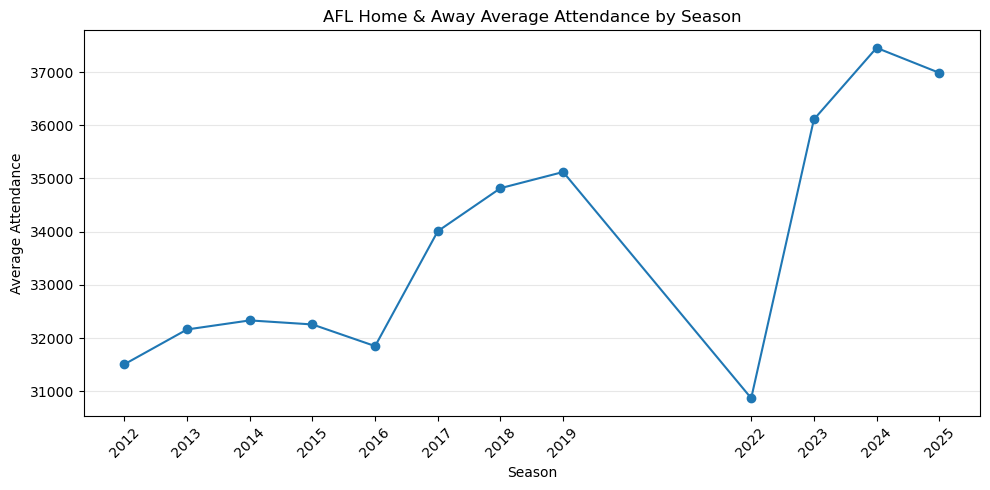

Saved chart to: C:\Users\DELL\afl-attendance-analytics\images\average_attendance_by_season.png


In [27]:
# I am visualising the Home & Away average attendance trend across the main analysis period.

plt.figure(figsize=(10, 5))

plt.plot(
    attendance_trend_df["season"],
    attendance_trend_df["home_away_average"],
    marker="o"
)

plt.title("AFL Home & Away Average Attendance by Season")
plt.xlabel("Season")
plt.ylabel("Average Attendance")
plt.xticks(attendance_trend_df["season"], rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

season_chart_path = IMAGES_DIR / "average_attendance_by_season.png"
plt.savefig(season_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", season_chart_path)

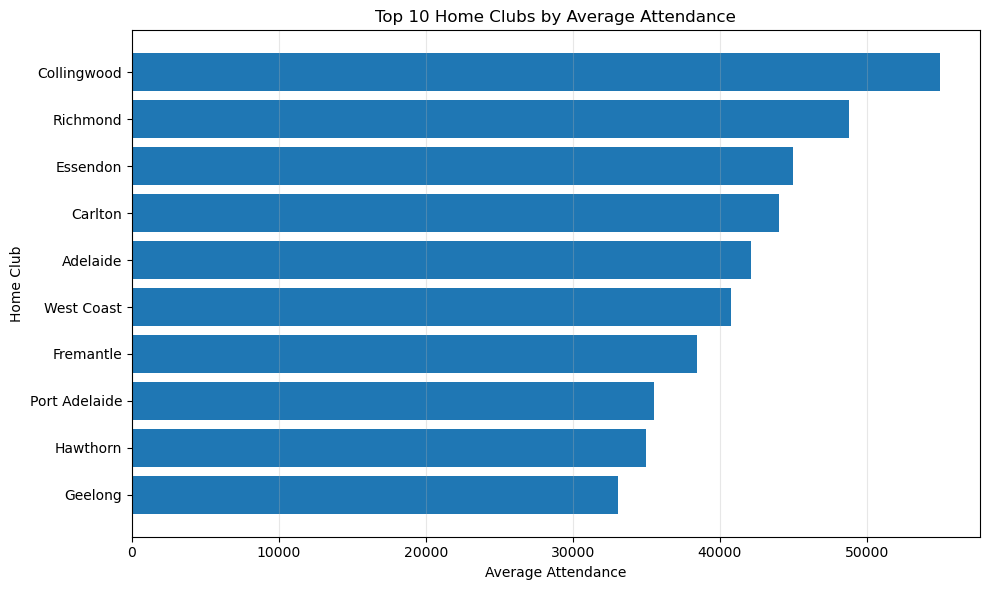

Saved chart to: C:\Users\DELL\afl-attendance-analytics\images\top_home_clubs_by_attendance.png


In [28]:
# I am visualising the top 10 home clubs by average Home & Away attendance.

top_10_clubs = club_attendance_df.head(10).sort_values("avg_attendance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_clubs["home_team"],
    top_10_clubs["avg_attendance"]
)

plt.title("Top 10 Home Clubs by Average Attendance")
plt.xlabel("Average Attendance")
plt.ylabel("Home Club")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

club_chart_path = IMAGES_DIR / "top_home_clubs_by_attendance.png"
plt.savefig(club_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", club_chart_path)

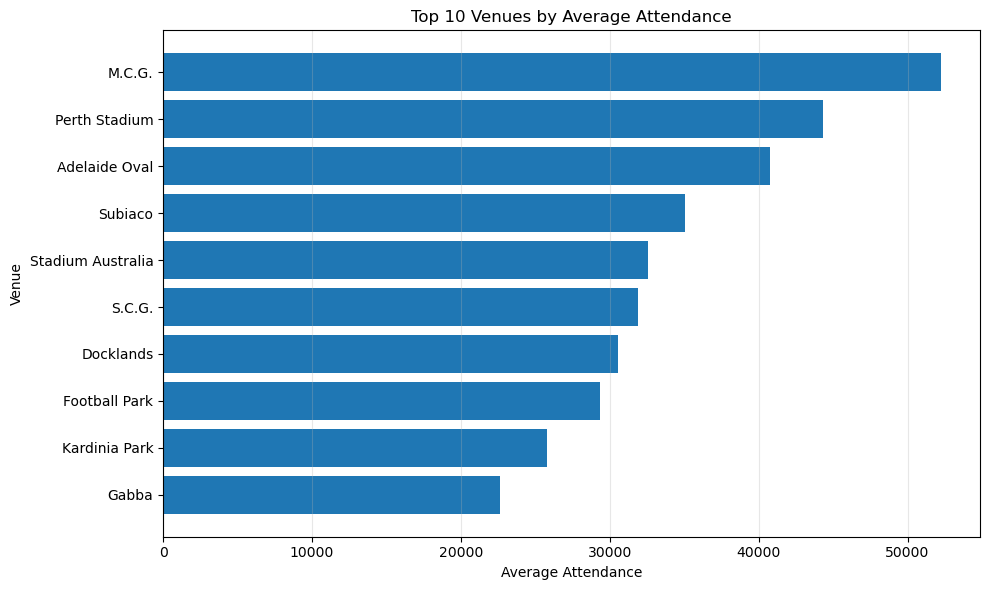

Saved chart to: C:\Users\DELL\afl-attendance-analytics\images\top_venues_by_attendance.png


In [29]:
# I am visualising the top 10 venues by average Home & Away attendance.

top_10_venues = venue_attendance_df.head(10).sort_values("avg_attendance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_venues["venue"],
    top_10_venues["avg_attendance"]
)

plt.title("Top 10 Venues by Average Attendance")
plt.xlabel("Average Attendance")
plt.ylabel("Venue")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

venue_chart_path = IMAGES_DIR / "top_venues_by_attendance.png"
plt.savefig(venue_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", venue_chart_path)

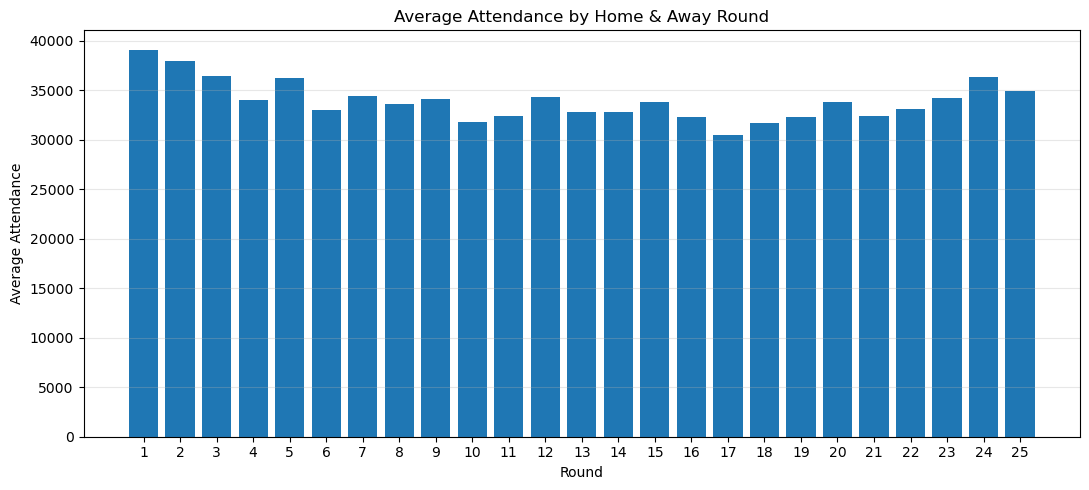

Saved chart to: C:\Users\DELL\afl-attendance-analytics\images\average_attendance_by_round.png


In [30]:
# I am visualising average attendance by Home & Away round.

plt.figure(figsize=(11, 5))

plt.bar(
    round_attendance_df["round"],
    round_attendance_df["avg_attendance"]
)

plt.title("Average Attendance by Home & Away Round")
plt.xlabel("Round")
plt.ylabel("Average Attendance")
plt.xticks(round_attendance_df["round"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

round_chart_path = IMAGES_DIR / "average_attendance_by_round.png"
plt.savefig(round_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", round_chart_path)

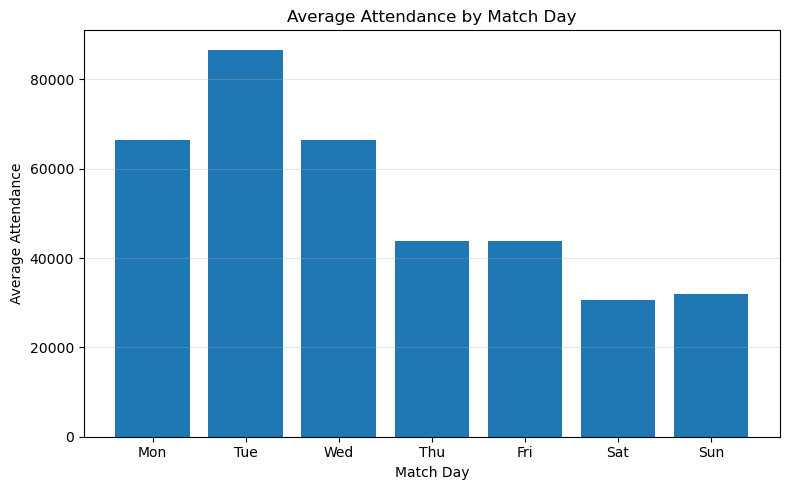

Saved chart to: C:\Users\DELL\afl-attendance-analytics\images\average_attendance_by_match_day.png


In [31]:
# I am visualising average attendance by match day.

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

day_plot_df = (
    day_attendance_df
    .set_index("match_day")
    .reindex([day for day in day_order if day in day_attendance_df["match_day"].values])
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    day_plot_df["match_day"],
    day_plot_df["avg_attendance"]
)

plt.title("Average Attendance by Match Day")
plt.xlabel("Match Day")
plt.ylabel("Average Attendance")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

day_chart_path = IMAGES_DIR / "average_attendance_by_match_day.png"
plt.savefig(day_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", day_chart_path)

In [32]:
# I am checking that all visualisation files were saved successfully.

saved_images = list(IMAGES_DIR.glob("*.png"))

for image_path in saved_images:
    print(image_path.name)

average_attendance_by_match_day.png
average_attendance_by_round.png
average_attendance_by_season.png
top_home_clubs_by_attendance.png
top_venues_by_attendance.png
